In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

In [2]:
import nltk
import re
from nltk.tokenize import word_tokenize

In [3]:
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report

In [5]:
from tqdm.notebook import tqdm

In [ ]:
from torchtext.vocab import build_vocab_from_iterator

In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.manual_seed(SEED)
g = torch.Generator()
g.manual_seed(SEED)

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [9]:
train_df = pd.read_csv('data/train_balanced.csv') 
val_df = pd.read_csv('data/validation_df.csv')
test_df = pd.read_csv('data/test_df.csv')

In [10]:
label_map = {'bad': 0, 'neutral': 1, 'good': 2}

In [11]:
train_df['Label'] = train_df['Score'].map(label_map)
val_df['Label'] = val_df['Score'].map(label_map)
test_df['Label'] = test_df['Score'].map(label_map)

In [ ]:
train_df.head()

We load pre-trained GloVe vectors ([glove.6B.300d.txt](https://www.kaggle.com/datasets/thanakomsn/glove6b300dtxt)) into a Python dictionary. This allows the model to use rich semantic representations learned from a massive external text corpus, helping it understand word meanings right from the start.

In [13]:
word_embeddings = {}
with open('glove.6B.300d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        word_embeddings[word] = coefs

We clean text converting everything to lowercase, removing HTML tags and URLs, and filtering out punctuation to keep only meaningful words and numbers.

In [14]:
def clean_and_tokenize(text):
    text = str(text).lower()
    
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalnum()]
    
    return tokens

In [15]:
tokenized_train = [clean_and_tokenize(t) for t in train_df['Text']]
tokenized_valid   = [clean_and_tokenize(t) for t in val_df['Text']]
tokenized_test  = [clean_and_tokenize(t) for t in test_df['Text']]

In [16]:
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'

In [17]:
vocab = build_vocab_from_iterator(tokenized_train,min_freq=10,specials=[PAD_TOKEN,UNK_TOKEN],special_first=True)

In [19]:
vocab.set_default_index(vocab[UNK_TOKEN])

In [18]:
print('Vocabulary size:', len(vocab))

Vocabulary size: 4845


In [20]:
class TextDataset(Dataset):
    def __init__(self, tokenized_texts, labels, vocab, max_len=50):
        
        processed_indices = []
        for tokens in tokenized_texts:
            indices = [vocab[w] for w in tokens]
            indices = indices[:max_len] + [0] * max(0, max_len - len(indices))
            
            processed_indices.append(indices)
            
        self.texts = torch.tensor(processed_indices, dtype=torch.long)
        self.labels = torch.tensor(labels.values, dtype=torch.long)
        
    def __len__(self):
        return len(self.texts)
        
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

In [21]:
MAX_LEN = 50
BATCH_SIZE = 128

In [23]:
train_dataset = TextDataset(tokenized_train, train_df['Label'], vocab, max_len=MAX_LEN)
val_dataset = TextDataset(tokenized_valid, val_df['Label'], vocab, max_len=MAX_LEN)
test_dataset = TextDataset(tokenized_test, test_df['Label'], vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [24]:
EMBEDDING_DIM = 300

In [25]:
vocab_size = len(vocab)

In [26]:
embedding_matrix = torch.zeros((vocab_size, EMBEDDING_DIM))
unmached_words = []
matched_words = 0
for word, idx in vocab.get_stoi().items():
    if word == PAD_TOKEN or word == UNK_TOKEN:
        continue
    vector = word_embeddings.get(word)
    if vector is not None:
        embedding_matrix[idx] = torch.tensor(vector)
        matched_words += 1
    else:
        unmached_words.append(word)

In [27]:
print('Number of unmached words: ',len(unmached_words),'number of mached words: ',matched_words)

Number of unmached words:  95 number of mached words:  4748


In [70]:
print(unmached_words[:20])

['ziplock', 'vitacoco', 'soooooo', 'shirataki', 'flavvors', 'convience', 'alittle', '0z', 'tasteing', 'snickerdoodle', 'decaffinated', 'delicous', 'chocolately', 'blackcurrent', 'blackcurrat', 'teavana', 'realllly', 'ntilde', 'kurig', 'pkgs']


We notice that the words missing from our vocabulary primarily consist of brand names, intentional typos, and common spelling errors, which aligns with the typical noise found in product reviews.

Bidirectional LSTM classifier that utilizes pre-trained embeddings

In [38]:
class SentimentLSTM(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim, n_layers,dropout):
        super().__init__()
        vocab_size, embedding_dim = embedding_matrix.shape
        
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix,freeze=True,padding_idx=0)
        
        
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers, batch_first=True, bidirectional=True)
        
        self.dropout = nn.Dropout(0.2)
        # *2 jer je bidirekcioni
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        
        x = torch.cat((forward_hidden, backward_hidden), dim=1)
        
        x = self.dropout(x)
        return self.fc(x)

In [39]:
def train_model(model, optimizer,scheduler, train_loader, valid_loader, epochs=5,save_path='models/best_LSTM.pth'):    
    model.to(device)

    criterion = nn.CrossEntropyLoss()

    metrics = {
        'train_loss': [],
        'train_accuracy': [],
        'train_f1' : [],
        'train_steps': [],
        'valid_loss': [],
        'valid_accuracy': [],
        'valid_f1': [],
        'valid_steps': [],
    }

    step = 0
    best_val_f1 = 0.0

    
    for epoch in range(epochs):
        model.train()
        train_loss_epoch = 0
        train_correct = 0
        train_samples = 0
        train_preds = []
        train_labels = []
        
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            inputs, labels = inputs.to(device), labels.to(device)
            batch_size = labels.size(0)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            _, predicted = torch.max(outputs, 1)
            correct = (predicted == labels).sum().item()
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            metrics['train_loss'].append(loss.item())
            metrics['train_accuracy'].append(correct / batch_size)
            metrics['train_steps'].append(step)

    
            train_loss_epoch += loss.item() * batch_size
            train_correct += correct
            train_samples += batch_size

            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

            step += 1
            
        
        train_loss = train_loss_epoch / train_samples
        train_accuracy = train_correct / train_samples
        train_f1 = f1_score(train_labels, train_preds, average='macro')
        
        metrics['train_f1'].append(train_f1)
            
        model.eval()
        with torch.no_grad():
            valid_loss_total = 0
            valid_correct = 0
            valid_samples = 0
            val_preds = []
            val_labels = []
            
            for inputs, labels in tqdm(valid_loader, desc=f"Epoha {epoch+1}/{epochs} [Valid]"):
                inputs, labels = inputs.to(device), labels.to(device)
                batch_size = labels.size(0)
            
                outputs = model(inputs)
                loss = nn.CrossEntropyLoss(reduction='sum')(outputs, labels)
                
                _, predicted = torch.max(outputs, 1)
                correct = (predicted == labels).sum().item()
                
                valid_loss_total += loss.item()
                valid_correct += correct
                valid_samples += batch_size
                
                val_preds.extend(predicted.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

            valid_loss = valid_loss_total / valid_samples
            valid_accuracy = valid_correct / valid_samples
            valid_f1 = f1_score(val_labels, val_preds, average='macro')

            scheduler.step(valid_f1)
            
            if valid_f1 > best_val_f1:
                best_val_f1 = valid_f1
    
                torch.save(model.state_dict(), save_path)
                
            metrics['valid_loss'].append(valid_loss)
            metrics['valid_accuracy'].append(valid_accuracy)
            metrics['valid_f1'].append(valid_f1)
            metrics['valid_steps'].append(step)

        
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} - Train Acc: {train_accuracy:.4f} | Val Loss: {valid_loss:.4f} - Val Acc: {valid_accuracy:.4f} - Val F1 (Macro): {valid_f1:.4f}")
        
    return metrics

In [63]:
def plot_all_metrics(metrics,save_path):
    epochs = range(1, len(metrics['valid_loss']) + 1)

    plt.figure(figsize=(18, 5))
    
    # Loss plot
    plt.subplot(1, 3, 1)
    plt.plot(metrics['train_steps'], metrics['train_loss'], label='Train Loss (per batch)', color='blue', alpha=0.3)
    plt.plot(metrics['valid_steps'], metrics['valid_loss'], label='Validation Loss', color='orange', marker='s', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.title('Loss Curves (Steps)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. Accuracy plot
    plt.subplot(1, 3, 2)
    plt.plot(metrics['train_steps'], metrics['train_accuracy'], label='Train Accuracy (per batch)', color='blue', alpha=0.3)
    plt.plot(metrics['valid_steps'], metrics['valid_accuracy'], label='Validation Accuracy', color='purple', marker='s', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curves')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 3. F1-Score Plot
    plt.subplot(1, 3, 3)
    plt.plot(epochs, metrics['train_f1'], 'o-', label='Train F1 (Macro)', color='blue')
    plt.plot(epochs, metrics['valid_f1'] if 'valid_f1' in metrics else metrics.get('valid_accuracy'), 's-', label='Val F1 (Macro)', color='green', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.title('Macro F1-Score Across Epochs')
    plt.xticks(epochs)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [55]:
def evaluate_and_plot_confusion_matrix(model, valid_loader,model_path,save_path):
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    class_names = ['Bad', 'Neutral', 'Good']
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    
    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds, target_names=class_names))

# Model training 

In [ ]:
vocab_size = len(vocab)  
EMBEDDING_DIM = 300      
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 
DROPOUT = 0.2
model = SentimentLSTM(embedding_matrix,HIDDEN_DIM,OUTPUT_DIM,N_LAYERS,DROPOUT)

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

metrics = train_model(
    model=model, 
    optimizer=optimizer,
    scheduler = scheduler,
    train_loader=train_loader,  
    valid_loader=val_loader,  
    epochs=20,
    save_path='models/best_LSTM_v1.pth'
)

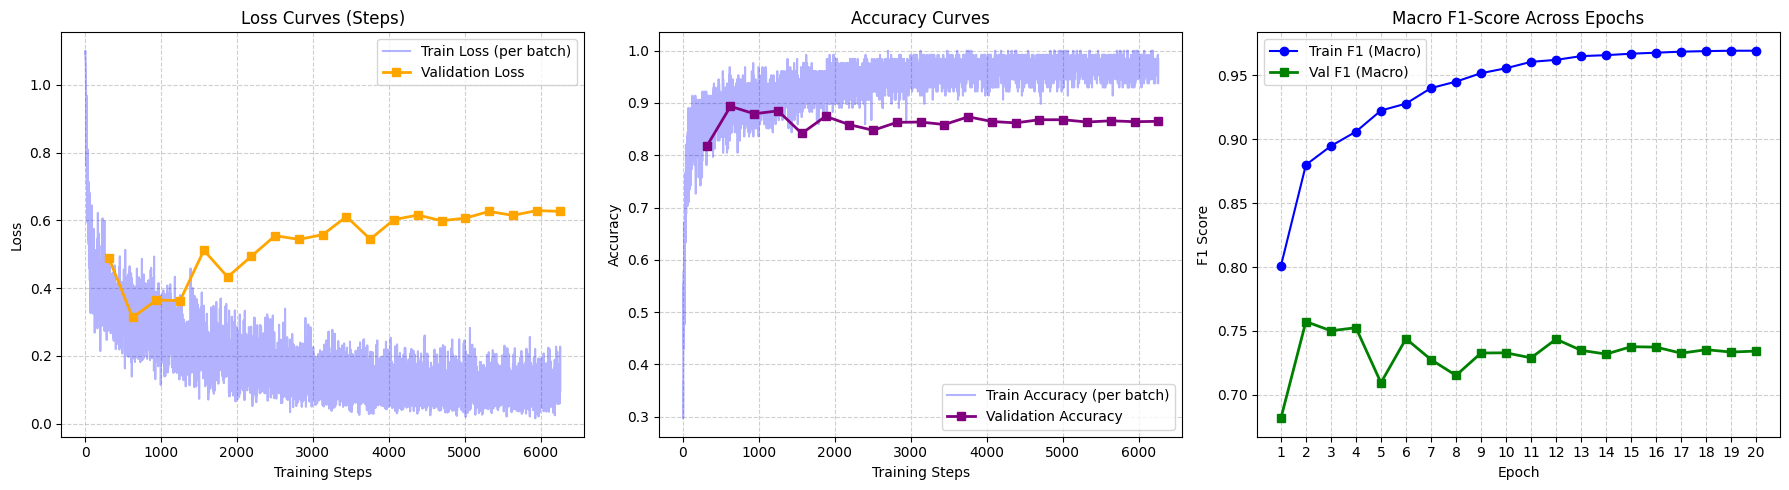

In [64]:
plot_all_metrics(metrics,'plots/LSTM_v1_training_metrics.png')

Based on the image, we can see that after the second epoch the model begins to overfit, as the training loss decreases while the validation loss increases. Similarly, looking at the accuracy, it steadily increases on the training set, whereas on the validation set it drops and then stagnates, the same applies to the F1-score. Based on this, we decide to save the model obtained at the end of the second epoch and attempt to improve it by strengthening regularization.

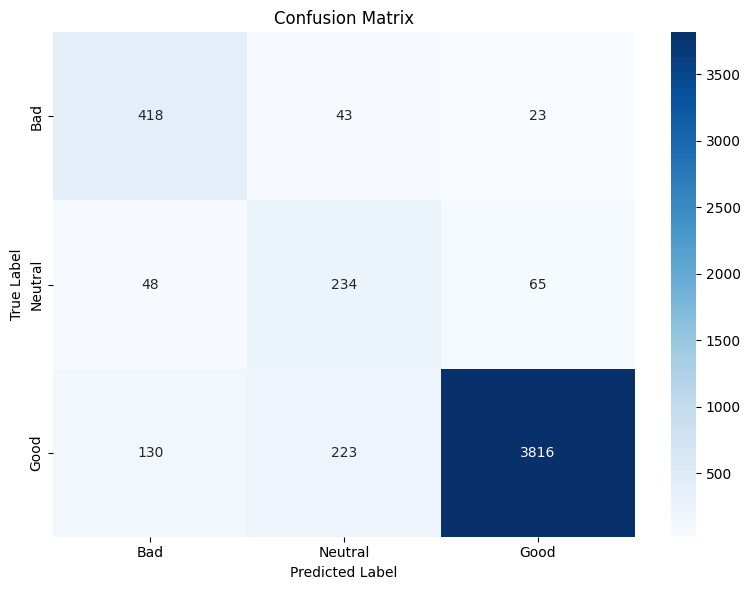


Classification Report:
              precision    recall  f1-score   support

         Bad       0.70      0.86      0.77       484
     Neutral       0.47      0.67      0.55       347
        Good       0.98      0.92      0.95      4169

    accuracy                           0.89      5000
   macro avg       0.72      0.82      0.76      5000
weighted avg       0.92      0.89      0.90      5000



In [72]:
evaluate_and_plot_confusion_matrix(model, val_loader, 'models/best_LSTM_v1.pth','plots/LSTM_v1_validation_confusion_matrix.png')

In [ ]:
vocab_size = len(vocab)  
EMBEDDING_DIM = 300      
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 
DROPOUT = 0.5
num_epochs = 10

model2 = SentimentLSTM(embedding_matrix,HIDDEN_DIM,OUTPUT_DIM,N_LAYERS,DROPOUT)
model2.load_state_dict(torch.load('models/best_LSTM_v1.pth', map_location=device))
model2.to(device)

optimizer2 = optim.Adam(model2.parameters(), lr=0.0005)
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='max', factor=0.5, patience=2)

metrics_2 = train_model(
    model=model2, 
    optimizer=optimizer2,
    scheduler = scheduler2,
    train_loader=train_loader,  
    valid_loader=val_loader,  
    epochs=num_epochs,
    save_path='models/best_LSTM_v2.pth'
)

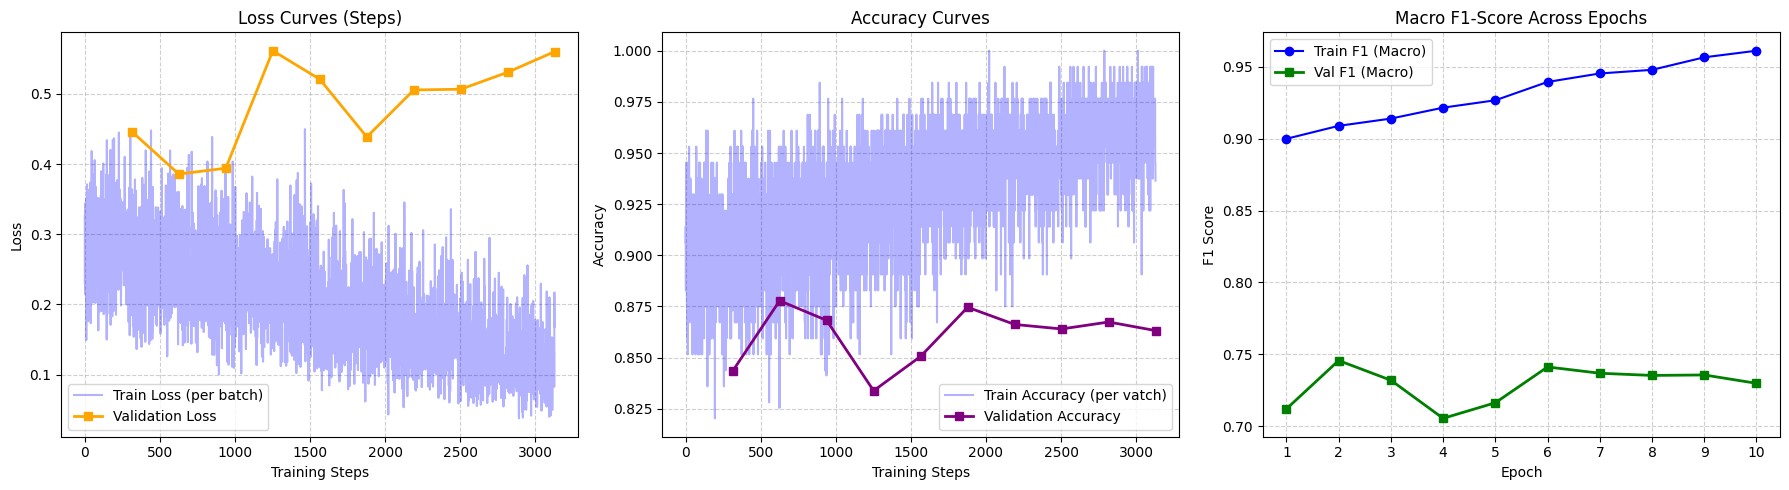

In [61]:
plot_all_metrics(metrics_2,'plots/LSTM_v2_training_metrics.png')

After increasing dropout and reducing the learning rate, we failed to achieve better results. Based on the image, we can see that the loss continued to decrease for the training set but not for the validation set, and both accuracy and F1-score increased only for the training set. Therefore, we will discard this attempt and try with even stronger regularization.

In [65]:
vocab_size = len(vocab)  
EMBEDDING_DIM = 300      
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 
DROPOUT = 0.5
num_epochs = 10

model3 = SentimentLSTM(embedding_matrix,HIDDEN_DIM,OUTPUT_DIM,N_LAYERS,DROPOUT)
model3.load_state_dict(torch.load('models/best_LSTM_v1.pth', map_location=device))
model3.to(device)

optimizer3 = optim.Adam(model3.parameters(), lr=0.0005,weight_decay=1e-4)
scheduler3 = optim.lr_scheduler.ReduceLROnPlateau(optimizer3, mode='max', factor=0.5, patience=2)

metrics_3 = train_model(
    model=model3, 
    optimizer=optimizer3,
    scheduler = scheduler3,
    train_loader=train_loader,  
    valid_loader=val_loader,  
    epochs=num_epochs,
    save_path='models/best_LSTM_v3.pth'
)

Epoch 1/10 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 1/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [1/10] | Train Loss: 0.2850 - Train Acc: 0.8979 | Val Loss: 0.3833 - Val Acc: 0.8714 - Val F1 (Macro): 0.7413


Epoch 2/10 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 2/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoha 9/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [9/10] | Train Loss: 0.1706 - Train Acc: 0.9424 | Val Loss: 0.5439 - Val Acc: 0.8462 - Val F1 (Macro): 0.7188


Epoch 10/10 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 10/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [10/10] | Train Loss: 0.1624 - Train Acc: 0.9466 | Val Loss: 0.5198 - Val Acc: 0.8630 - Val F1 (Macro): 0.7323


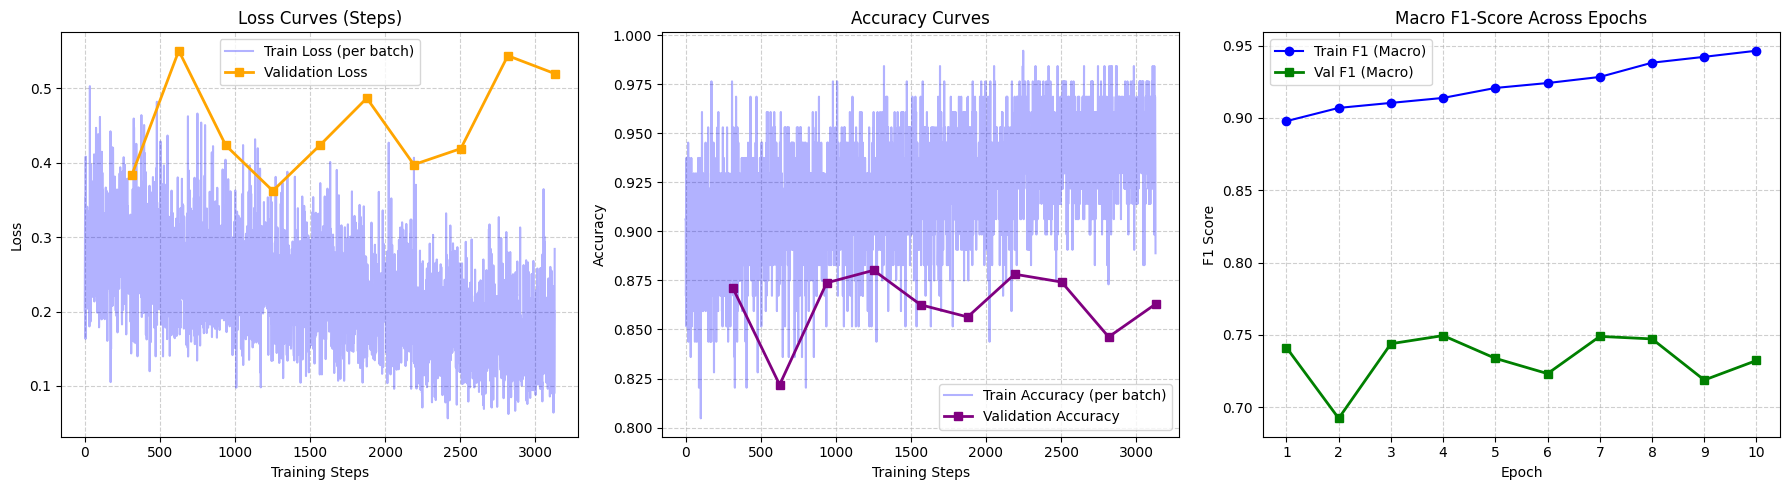

In [67]:
plot_all_metrics(metrics_3,'plots/LSTM_v3_training_metrics.png')

We notice that the validation loss is more unstable than before, while all training metrics continue to improve.

In [ ]:
vocab_size = len(vocab)  
EMBEDDING_DIM = 300      
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 
DROPOUT = 0.5
num_epochs = 10

model4 = SentimentLSTM(embedding_matrix,HIDDEN_DIM,OUTPUT_DIM,N_LAYERS,DROPOUT)
model4.load_state_dict(torch.load('models/best_LSTM_v1.pth', map_location=device))
model4.to(device)

optimizer4 = optim.Adam(model4.parameters(), lr=0.0005,weight_decay=1e-3)
scheduler4 = optim.lr_scheduler.ReduceLROnPlateau(optimizer3, mode='max', factor=0.5, patience=2)

metrics_4 = train_model(
    model=model4, 
    optimizer=optimizer4,
    scheduler = scheduler4,
    train_loader=train_loader,  
    valid_loader=val_loader,  
    epochs=num_epochs,
    save_path='models/best_LSTM_v4.pth'
)

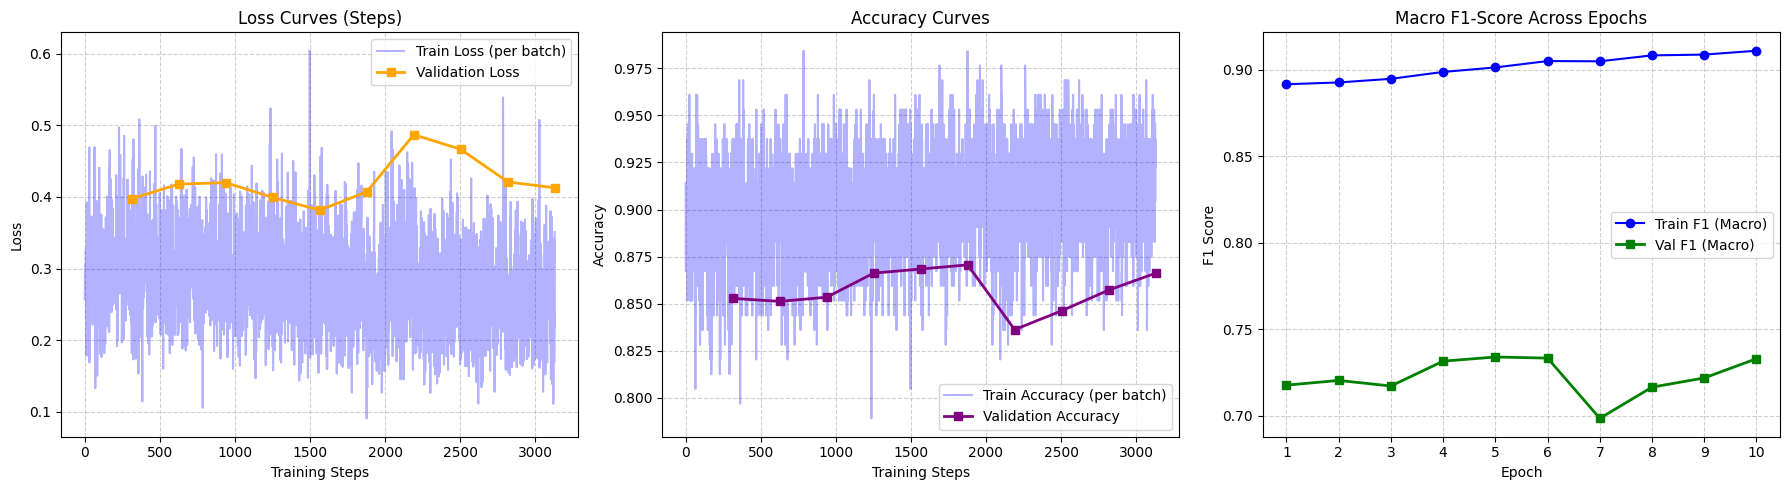

In [71]:
plot_all_metrics(metrics_4,'plots/LSTM_v4_training_metrics.png')

By increasing weight_decay, we obtained slightly poorer results on both the training and validation sets, therefore, we kept the initial configuration as our final model.

# Evaluation on test dataset

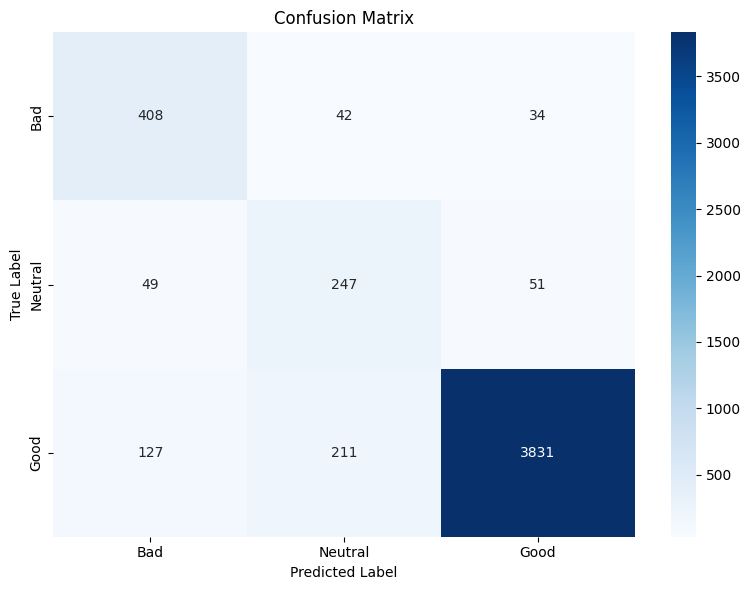


Classification Report:
              precision    recall  f1-score   support

         Bad       0.70      0.84      0.76       484
     Neutral       0.49      0.71      0.58       347
        Good       0.98      0.92      0.95      4169

    accuracy                           0.90      5000
   macro avg       0.72      0.82      0.76      5000
weighted avg       0.92      0.90      0.90      5000



In [75]:
evaluate_and_plot_confusion_matrix(model,test_loader, 'models/best_LSTM_v1.pth','plots/LSTM_final_test_confusion_matrix.png')

We tested our model on 5,000 unseen test samples and the results on the test set are very similar to our validation results. The model hits an accuracy of 0.90 with a macro F1-score of 0.76. Notably, the precision for the neutral class remains quite low (0.49 on the test set) in both cases, indicating that the model struggles to correctly identify and isolate neutral reviews without confusing them with other classes.

## Wrong predicted examples

In [83]:
model.load_state_dict(torch.load('models/best_LSTM_v1.pth', map_location=device))

model.eval()
all_preds = []
all_labels = []
 

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [84]:
errors = np.where(all_labels != all_preds)[0]

In [85]:
num_to_labels = {0: 'Bad', 1: 'Neutral', 2: 'Good'}
for idx in errors[:10]:
    text_rec = test_df.iloc[idx]['Text'] 
    
    print(text_rec)
    print(f"True class: {num_to_labels[all_labels[idx]]} | Predicted class: {num_to_labels[all_preds[idx]]}")
    print("-" * 50)

I was looking for 'apple crisps' but didn't want artificial ingredients or sugar added.  These fit the bill! Deliciously tart and semi- sweet.  Crisp enough but still a bit chewy...the best part?  My kids HATE them! Yum, Yum...more for me:-)
True class: Good | Predicted class: Bad
--------------------------------------------------
Sometimes these markers work great and sometimes not so much. I do think that they work better then anything I bought at the store.
True class: Neutral | Predicted class: Good
--------------------------------------------------
Breakfast Blend is mild and full favor.<br />Good for all day not just morning.
True class: Neutral | Predicted class: Good
--------------------------------------------------
These cookies are just da bomb and their calorie count is relatively low at the same time. Get these and you'll know why people in Belgium and France even eat these for breakfast or lunch.
True class: Good | Predicted class: Neutral
--------------------------------

Despite class balancing, the model still struggles because it gets confused by sarcasm and mixed sentiments within the same review. For instance, the model incorrectly classifies good review as bad because it reacts to isolated words like 'HATE' even when the rest of the sentence is playful and positive ('My kids HATE them... more for me').

A review stating 'I simply spread a bit on the carpet and let them frolic in it! Does not stain and easily removed with a vacuum!' was misclassified as neutral simply because it describes the practical interaction without using positive vocabulary.

The model struggles when negation words are used to praise a product rather than criticize it. For example, a glowing review praising clean ingredients ('That's the one and only ingredient in this oatmeal. No sugar. No salt. No preservatives... I love this oatmeal!') was misclassified as bad because the repeated presence of the word 'no' triggered a false negative association in the architecture, overriding the final positive concluding statement.